# U.S. Macroeconomic Indicators — Transmission & Sentiment

**Author:** Saqib Ali Khan  
Project for the *Visualization for AI* course, BSc Artificial Intelligence, Johannes Kepler University Linz.

This notebook goes deeper: a lagged-correlation study of how Federal Funds Rate changes transmit across the economy in three monetary regimes, and a significance-tested analysis of whether consumer sentiment reacts asymmetrically to bad versus good news of comparable magnitude.

*Data is pulled live from the FRED API; see the repository README for the full project overview.*

## Objectives

This notebook investigates two questions about how shocks move through the U.S.
economy (2000–2026); the full hypotheses and findings are in the **Results**
section at the end.

- **B.1 — Rate transmission:** How does a change in the Federal Funds Rate propagate
  to mortgage rates, the S&P 500, inflation, and unemployment across different lags,
  and how does that differ across three monetary-policy regimes?
- **B.2 — Sentiment asymmetry:** Does consumer sentiment react more sharply to
  worsening conditions than to improvements of comparable magnitude (loss aversion)?

## Dataset

The FRED Macroeconomic Bundle combines eight U.S. economic time series 
from the Federal Reserve Bank of St. Louis (2000–2026): Federal Funds 
Rate, 2- and 10-year Treasury yields, CPI, unemployment rate, S&P 500, 
30-year mortgage rate, and consumer sentiment. Resampled to monthly 
frequency and merged into ~310 rows. Covers major events including the 
2008 financial crisis, 2020 COVID shock, and 2022 inflation spike.

# Code

## Imports

We import the libraries needed for data loading, wrangling, and visualization. This submission adds Plotly for interactive charts and Kaleido for exporting static images.

In [118]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import requests
from io import StringIO
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots

In [119]:
import kaleido
print(kaleido.__version__)

0.2.1


## Data Loading

We download all 8 FRED series using their public CSV API, reusing the same approach from the foundational_analysis.

In [120]:
BASE_URL = "https://fred.stlouisfed.org/graph/fredgraph.csv?id="

SERIES = {
    "FEDFUNDS":     "Effective Federal Funds Rate (%)",
    "DGS10":        "10-Year Treasury Yield (%)",
    "DGS2":         "2-Year Treasury Yield (%)",
    "CPIAUCSL":     "Consumer Price Index",
    "UNRATE":       "Unemployment Rate (%)",
    "SP500":        "S&P 500 Index",
    "MORTGAGE30US": "30-Year Mortgage Rate (%)",
    "UMCSENT":      "Consumer Sentiment",
}

def fetch_fred(series_id):
    url = BASE_URL + series_id
    response = requests.get(url, timeout=30)
    response.raise_for_status()
    df = pd.read_csv(StringIO(response.text))
    df["observation_date"] = pd.to_datetime(df["observation_date"])
    df = df.set_index("observation_date")
    df.index.name = "DATE"
    df.columns = [series_id]
    df[series_id] = pd.to_numeric(df[series_id], errors="coerce")
    return df[series_id]

raw = {}
for sid in SERIES:
    print(f"Downloading {sid}...")
    raw[sid] = fetch_fred(sid)

print("\nAll series downloaded successfully.")


All series downloaded successfully.


## Resampling to Monthly Frequency

We resample all series to month-end frequency by taking the last available value of each month.

In [121]:
dgs10_m    = raw["DGS10"].resample("ME").last()
dgs2_m     = raw["DGS2"].resample("ME").last()
sp500_m    = raw["SP500"].resample("ME").last()
mort_m     = raw["MORTGAGE30US"].resample("ME").last()
fedfunds_m = raw["FEDFUNDS"].resample("ME").last()
cpi_m      = raw["CPIAUCSL"].resample("ME").last()
unrate_m   = raw["UNRATE"].resample("ME").last()
umcsent_m  = raw["UMCSENT"].resample("ME").last()

print("Resampling complete.")

Resampling complete.


## Merging into one DataFrame

We merge all 8 resampled series into a single DataFrame and filter to keep only data from January 2000 onward.

In [122]:
df = pd.DataFrame({
    "FEDFUNDS":     fedfunds_m,
    "DGS10":        dgs10_m,
    "DGS2":         dgs2_m,
    "CPIAUCSL":     cpi_m,
    "UNRATE":       unrate_m,
    "SP500":        sp500_m,
    "MORTGAGE30US": mort_m,
    "UMCSENT":      umcsent_m,
})
df = df[df.index >= "2000-01-01"]

print(f"Shape: {df.shape}")
print(f"\nMissing values per column:")
print(df.isnull().sum())
df.head()

Shape: (318, 8)

Missing values per column:
FEDFUNDS          1
DGS10             0
DGS2              0
CPIAUCSL          2
UNRATE            2
SP500           197
MORTGAGE30US      0
UMCSENT           2
dtype: int64


,FEDFUNDS,DGS10,DGS2,CPIAUCSL,UNRATE,SP500,MORTGAGE30US,UMCSENT
DATE,,,,,,,,
2000-01-31,5.45,6.68,6.61,169.3,4.0,NaN,8.25,112.0
2000-02-29,5.73,6.42,6.53,170.0,4.1,NaN,8.31,111.3
2000-03-31,5.85,6.03,6.50,171.0,4.0,NaN,8.23,107.1
2000-04-30,6.02,6.23,6.68,170.9,3.8,NaN,8.13,109.2
2000-05-31,6.27,6.29,6.69,171.2,4.0,NaN,8.62,110.7


## Handling Missing Values

We use forward-fill followed by backward-fill to handle any remaining gaps.

In [123]:
df = df.ffill().bfill()

print("Missing values after fill:")
print(df.isnull().sum())

Missing values after fill:
FEDFUNDS        0
DGS10           0
DGS2            0
CPIAUCSL        0
UNRATE          0
SP500           0
MORTGAGE30US    0
UMCSENT         0
dtype: int64


## Computing Derived Columns

We compute the yield curve spread (SPREAD) and year-over-year inflation 
(INFLATION_YOY), and define the official NBER recession periods.

In [124]:
df["SPREAD"] = df["DGS10"] - df["DGS2"]
df["INFLATION_YOY"] = df["CPIAUCSL"].pct_change(12) * 100

RECESSIONS = [
    ("2001-03-01", "2001-11-01"),
    ("2007-12-01", "2009-06-01"),
    ("2020-02-01", "2020-04-01"),
]

print("Derived columns added.")
print(f"\nFinal dataset shape: {df.shape}")
df.head()

Derived columns added.

Final dataset shape: (318, 10)


,FEDFUNDS,DGS10,DGS2,CPIAUCSL,UNRATE,SP500,MORTGAGE30US,UMCSENT,SPREAD,INFLATION_YOY
DATE,,,,,,,,,,
2000-01-31,5.45,6.68,6.61,169.3,4.0,2098.86,8.25,112.0,0.07,NaN
2000-02-29,5.73,6.42,6.53,170.0,4.1,2098.86,8.31,111.3,-0.11,NaN
2000-03-31,5.85,6.03,6.50,171.0,4.0,2098.86,8.23,107.1,-0.47,NaN
2000-04-30,6.02,6.23,6.68,170.9,3.8,2098.86,8.13,109.2,-0.45,NaN
2000-05-31,6.27,6.29,6.69,171.2,4.0,2098.86,8.62,110.7,-0.40,NaN


## Visualization B.1 — Fed Rate Transmission Heatmap

We compute month-over-month changes for each variable (percentage-point 
changes for rate variables, percentage changes for price-level variables) 
to avoid spurious correlation from long-term trends. We then calculate 
correlation between Fed Funds Rate changes and each target variable's 
changes at multiple lags, separately for three macroeconomic regimes. 
The result is rendered as three side-by-side heatmap panels in a single 
interactive Plotly figure, allowing direct visual comparison across regimes.

In [125]:
df["FEDFUNDS_CHANGE"]  = df["FEDFUNDS"].diff()
df["MORTGAGE_CHANGE"]  = df["MORTGAGE30US"].diff()
df["UNRATE_CHANGE"]    = df["UNRATE"].diff()
df["SP500_CHANGE"]     = df["SP500"].pct_change() * 100
df["CPI_CHANGE"]       = df["CPIAUCSL"].pct_change() * 100

print("Change columns added.")
df[["FEDFUNDS_CHANGE", "MORTGAGE_CHANGE", "UNRATE_CHANGE",
    "SP500_CHANGE", "CPI_CHANGE"]].head(15)

Change columns added.


,FEDFUNDS_CHANGE,MORTGAGE_CHANGE,UNRATE_CHANGE,SP500_CHANGE,CPI_CHANGE
DATE,,,,,
2000-01-31,NaN,NaN,NaN,NaN,NaN
2000-02-29,0.28,0.06,0.1,0.0,0.413467
2000-03-31,0.12,-0.08,-0.1,0.0,0.588235
2000-04-30,0.17,-0.10,-0.2,0.0,-0.058480
2000-05-31,0.25,0.49,0.2,0.0,0.175541
2000-06-30,0.26,-0.40,0.0,0.0,0.584112
2000-07-31,0.01,-0.09,0.0,0.0,0.290360
2000-08-31,-0.04,-0.14,0.1,0.0,0.000000
2000-09-30,0.02,-0.11,-0.2,0.0,0.521135


## Computing Lagged Correlations per Regime

We define three macroeconomic regimes by date range and compute the 
correlation between Fed Funds Rate changes and each target variable's 
changes at lags of 0, 6, 12, 18, 24, and 36 months, separately within 
each regime. A positive lag means the target variable's response is 
measured that many months after the Fed Funds Rate change.

While preparing this, we discovered that FRED's S&P 500 series only 
provides real data from June 2016 onward — a known licensing 
limitation on this specific series. Our earlier forward/backward-fill 
step had filled the 2000–2016 gap with a constant value, which would 
produce a misleading, undefined correlation if included. We handle 
this by restricting S&P 500 correlations to its genuine data window 
and explicitly marking any combination with fewer than 12 real months 
of data as missing rather than computing a false number.

In [126]:
# Define the three regimes by date range
REGIMES = {
    "Pre-2008\n(2000–2007)":      ("2000-01-01", "2007-12-31"),
    "Zero-Rate Era\n(2008–2020)": ("2008-01-01", "2020-02-29"),
    "Post-COVID\n(2020–2026)":    ("2020-03-01", "2026-12-31"),
}

# Target variables and their change columns
TARGETS = {
    "Mortgage Rate":  "MORTGAGE_CHANGE",
    "S&P 500":        "SP500_CHANGE",
    "Inflation (CPI)":"CPI_CHANGE",
    "Unemployment":   "UNRATE_CHANGE",
}

LAGS = [0, 6, 12, 18, 24, 36]

# S&P 500's real data only starts in 2016 (FRED licensing limitation);
# everything before that was backfilled with a constant value
SP500_DATA_START = raw["SP500"].index.min()
MIN_VALID_MONTHS = 12  # require at least 12 real months to compute a correlation

print(f"S&P 500 real data range: {SP500_DATA_START.strftime('%Y-%m-%d')} "
      f"to {raw['SP500'].index.max().strftime('%Y-%m-%d')}")

def compute_correlation_matrix(regime_start, regime_end):
    """
    For one regime, compute correlation between FEDFUNDS_CHANGE and each
    target's change, at each lag. Returns a DataFrame: rows=targets, cols=lags.
    """
    regime_df = df.loc[regime_start:regime_end]
    result = pd.DataFrame(index=list(TARGETS.keys()), columns=LAGS, dtype=float)

    for target_name, target_col in TARGETS.items():
        # Restrict S&P 500 to its genuine data window to avoid correlating
        # against an artificially constant backfilled series
        if target_col == "SP500_CHANGE":
            valid_df = regime_df[regime_df.index >= SP500_DATA_START]
        else:
            valid_df = regime_df

        for lag in LAGS:
            n_real_points = valid_df[target_col].notna().sum()
            if n_real_points < MIN_VALID_MONTHS:
                corr = float("nan")  # explicitly mark as insufficient data
            else:
                fed = valid_df["FEDFUNDS_CHANGE"]
                target_shifted = valid_df[target_col].shift(-lag)
                corr = fed.corr(target_shifted)
            result.loc[target_name, lag] = corr

    return result

# Compute for all three regimes
corr_matrices = {}
for regime_name, (start, end) in REGIMES.items():
    corr_matrices[regime_name] = compute_correlation_matrix(start, end)
    print(f"\n=== {regime_name.replace(chr(10), ' ')} ===")
    print(corr_matrices[regime_name].round(2))

S&P 500 real data range: 2016-06-20 to 2026-06-18

=== Pre-2008 (2000–2007) ===
                   0     6     12    18    24    36
Mortgage Rate    0.03  0.04  0.18  0.09  0.04 -0.18
S&P 500           NaN   NaN   NaN   NaN   NaN   NaN
Inflation (CPI)  0.10  0.15  0.11  0.08  0.11 -0.02
Unemployment    -0.35 -0.37 -0.01  0.02  0.07  0.24

=== Zero-Rate Era (2008–2020) ===
                   0     6     12    18    24    36
Mortgage Rate   -0.01  0.03  0.06  0.12 -0.06 -0.03
S&P 500         -0.10  0.25  0.20  0.10  0.22  0.07
Inflation (CPI)  0.29  0.18 -0.06  0.01  0.06 -0.16
Unemployment    -0.20 -0.34 -0.39 -0.04 -0.04  0.15

=== Post-COVID (2020–2026) ===
                   0     6     12    18    24    36
Mortgage Rate    0.10  0.03 -0.01 -0.17 -0.29 -0.04
S&P 500          0.02  0.11  0.01  0.13  0.14  0.03
Inflation (CPI)  0.37 -0.01 -0.18 -0.32 -0.38  0.02
Unemployment    -0.33  0.44  0.15  0.39  0.25  0.16


## Visualization B.1 — Fed Rate Transmission Heatmap (Final)

Three side-by-side heatmap panels, one per regime, showing correlation 
between Fed Funds Rate changes and four target variables across six 
lags. Missing S&P 500 data (FRED only provides data from 2016 onward) 
is marked with diagonal hatching rather than computed misleadingly. 
Bold boxes highlight the three cells that anchor our key findings.

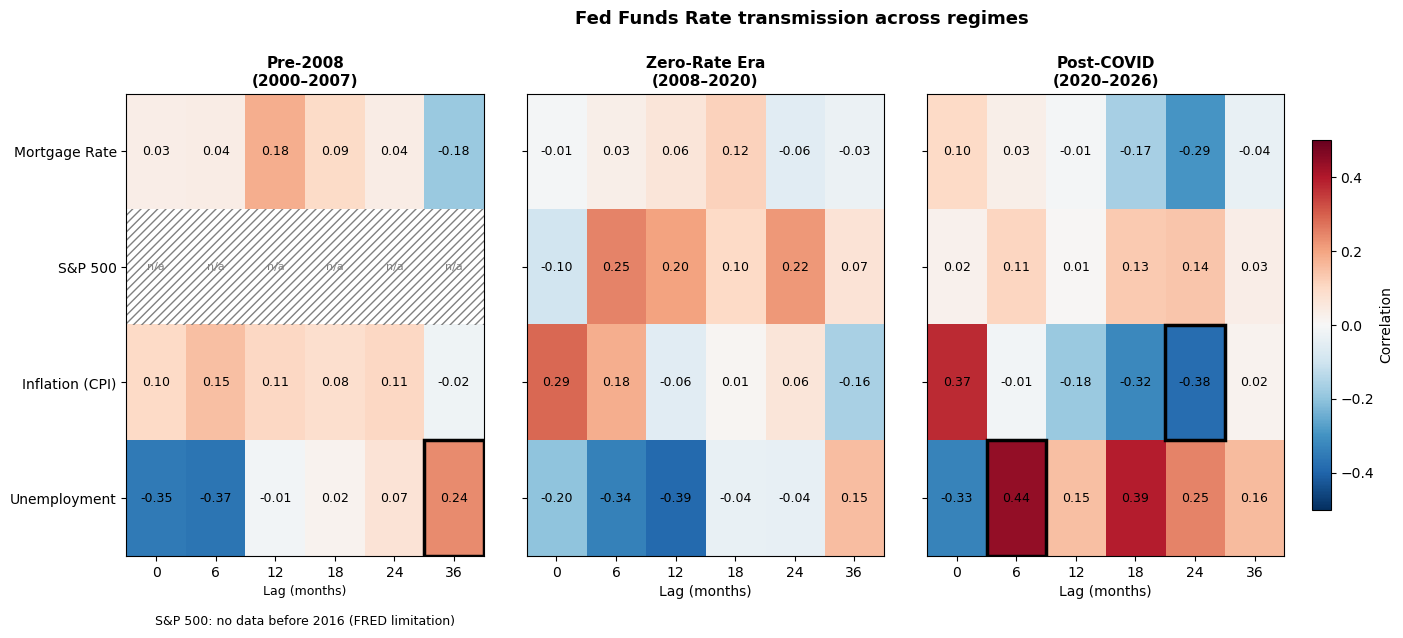

In [127]:
def plot_b1_heatmap():
    fig, axes = plt.subplots(1, 3, figsize=(18, 6.0))

    # Reordered by typical transmission speed: fastest-reacting variables
    # nearer the top, slowest nearer the bottom. S&P 500 kept second
    # (not top) so the partially-hatched row doesn't dominate first glance.
    targets_list = ["Mortgage Rate", "S&P 500", "Inflation (CPI)", "Unemployment"]

    highlight_cells = [
        (0, targets_list.index("Unemployment"), LAGS.index(36)),
        (2, targets_list.index("Unemployment"), LAGS.index(6)),
        (2, targets_list.index("Inflation (CPI)"), LAGS.index(24)),
    ]

    for idx, (ax, (regime_name, matrix)) in enumerate(zip(axes, corr_matrices.items())):
        data = matrix.loc[targets_list].values.astype(float)
        im = ax.imshow(data, cmap="RdBu_r", vmin=-0.5, vmax=0.5, aspect="auto")

        ax.set_xticks(range(len(LAGS)))
        ax.set_xticklabels(LAGS)
        ax.set_yticks(range(len(targets_list)))
        ax.set_yticklabels(targets_list if idx == 0 else [])

        # The S&P 500 explanatory note is folded into this panel's own
        # xlabel (as a second line), so it's anchored to the axes itself
        # rather than floating in figure space — this keeps it correctly
        # positioned even after bbox_inches="tight" cropping on save.
        if matrix.loc["S&P 500"].isna().any():
            ax.set_xlabel("Lag (months)\n\nS&P 500: no data before 2016 (FRED limitation)",
                           fontsize=9)
        else:
            ax.set_xlabel("Lag (months)")

        ax.set_title(regime_name, fontsize=11, fontweight="bold")

        for i in range(data.shape[0]):
            for j in range(data.shape[1]):
                val = data[i, j]
                if pd.isna(val):
                    ax.add_patch(mpatches.Rectangle(
                        (j - 0.5, i - 0.5), 1, 1,
                        fill=False, hatch="////", edgecolor="grey", linewidth=0))
                    ax.text(j, i, "n/a", ha="center", va="center",
                            fontsize=8, color="grey")
                else:
                    ax.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=9)

        for h_idx, h_row, h_col in highlight_cells:
            if h_idx == idx:
                ax.add_patch(mpatches.Rectangle(
                    (h_col - 0.5, h_row - 0.5), 1, 1,
                    fill=False, edgecolor="black", linewidth=2.5))

    fig.subplots_adjust(wspace=0.12)
    fig.colorbar(im, ax=axes, shrink=0.8, label="Correlation",
                 location="right", pad=0.02)
    fig.suptitle("Fed Funds Rate transmission across regimes", fontsize=13,
                 fontweight="bold", y=1.02)
    plt.savefig("b1_heatmap.png", dpi=150, bbox_inches="tight")
    plt.show()

plot_b1_heatmap()

## B.1 Prototype — Option B: Line Chart (Correlation vs Lag)

Three line-chart panels side by side, one per regime. Each line 
represents one target variable's correlation with the Fed Funds Rate 
across different lags, making the shape of the transmission effect 
(when it peaks, when it fades) easier to see than in a heatmap.

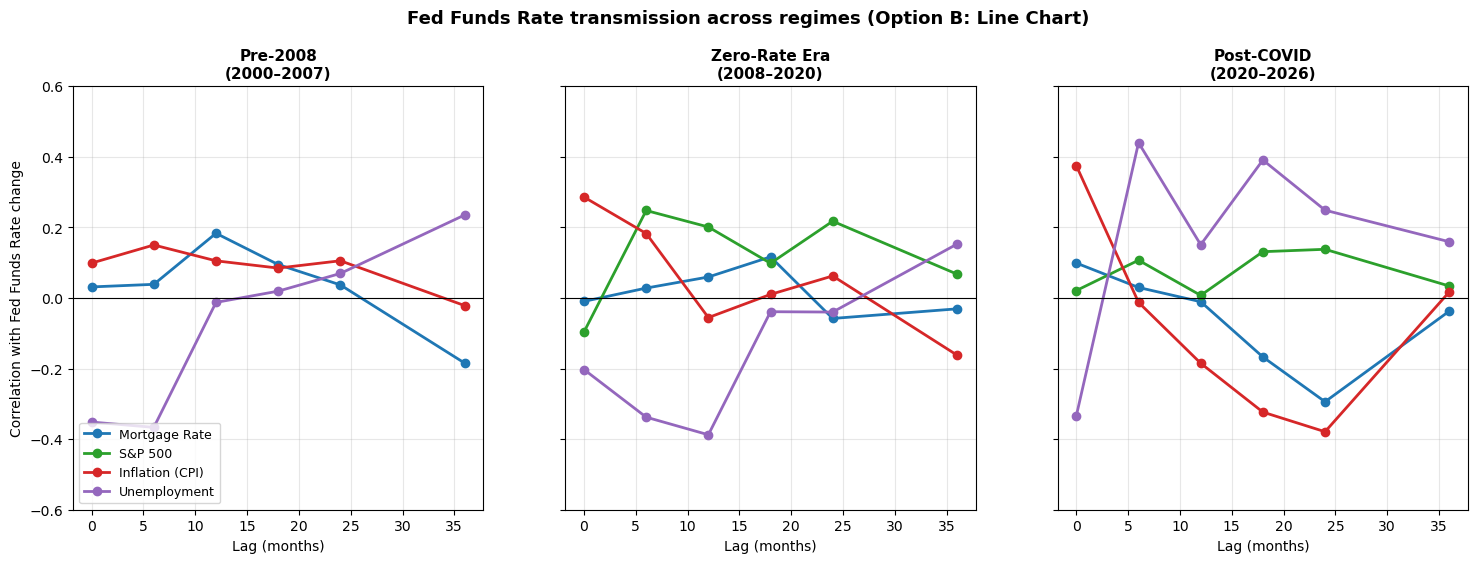

In [128]:
def plot_b1_lines():
    fig, axes = plt.subplots(1, 3, figsize=(18, 5.5), sharey=True)

    colors = {"Mortgage Rate": "#1f77b4", "S&P 500": "#2ca02c",
              "Inflation (CPI)": "#d62728", "Unemployment": "#9467bd"}

    for ax, (regime_name, matrix) in zip(axes, corr_matrices.items()):
        for target_name in TARGETS.keys():
            ax.plot(LAGS, matrix.loc[target_name].values,
                    marker="o", label=target_name,
                    color=colors[target_name], linewidth=2)

        ax.axhline(0, color="black", linewidth=0.8, linestyle="-")
        ax.set_xlabel("Lag (months)")
        ax.set_title(regime_name, fontsize=11, fontweight="bold")
        ax.set_ylim(-0.6, 0.6)
        ax.grid(alpha=0.3)

    axes[0].set_ylabel("Correlation with Fed Funds Rate change")
    axes[0].legend(loc="lower left", fontsize=9)
    fig.suptitle("Fed Funds Rate transmission across regimes (Option B: Line Chart)",
                 fontsize=13, fontweight="bold", y=1.02)
    plt.savefig("b1_option_b_lines.png", dpi=150, bbox_inches="tight")
    plt.show()

plot_b1_lines()

## B.1 Interactive Version — Plotly Dropdown Heatmap

We rebuild the heatmap as a single interactive Plotly figure. A dropdown 
menu lets the user select a regime, dynamically updating the heatmap's 
values and title. Hovering over any cell shows the exact correlation 
value. A static PNG is also saved as a GitHub preview fallback.

In [ ]:
def plot_b1_interactive():
    targets_list = list(TARGETS.keys())
    regime_names = list(corr_matrices.keys())

    z_data = [corr_matrices[r].values.astype(float) for r in regime_names]
    text_data = [
        [["n/a" if pd.isna(v) else f"{v:.2f}" for v in row] for row in matrix]
        for matrix in z_data
    ]

    fig = go.Figure(
        data=go.Heatmap(
            z=z_data[0],
            x=[str(l) for l in LAGS],
            y=targets_list,
            colorscale="RdBu_r",
            zmid=0, zmin=-0.5, zmax=0.5,
            text=text_data[0],
            texttemplate="%{text}",
            hovertemplate="Variable: %{y}<br>Lag: %{x} months<br>Correlation: %{z:.2f}<extra></extra>",
            colorbar=dict(title="Correlation"),
        )
    )

    buttons = []
    for i, regime_name in enumerate(regime_names):
        clean_name = regime_name.replace("\n", " ")
        buttons.append(dict(
            label=clean_name,
            method="update",
            args=[{"z": [z_data[i]], "text": [text_data[i]]},
                  {"title": f"Fed Funds Rate transmission — {clean_name}"}]
        ))

    fig.update_layout(
        updatemenus=[dict(
            buttons=buttons,
            direction="down",
            x=1.2, y=1.15,
            showactive=True,
        )],
        title=f"Fed Funds Rate transmission — {regime_names[0].replace(chr(10),' ')}",
        xaxis_title="Lag (months)",
        width=750, height=500,
    )

    fig.show()

plot_b1_interactive()

### B.2 – Data Preparation

To test whether sentiment reacts asymmetrically to good versus bad news, 
we classify each month by the direction of its unemployment change 
(`UNRATE_CHANGE`): months where unemployment rose are **bad news**, months 
where it fell are **good news**. Months with no change are excluded to keep 
the two groups clean. For each month we pair this label with the 
corresponding month-over-month change in consumer sentiment 
(`UMCSENT_CHANGE`).

A first look at the group means is already suggestive: sentiment falls by 
an average of −0.52 points in bad-news months but rises by only +0.32 
points in good-news months — a drop roughly 1.6× larger than the 
comparable rise. However, means alone can hide very different underlying 
distributions (cf. Anscombe's Quartet), and they do not yet account for 
the *size* of the underlying shock. The visualization below addresses both.

In [130]:
# ── B.2 Data Preparation (shared across all chart options) ────────────────────

# Month-over-month change in consumer sentiment
df["UMCSENT_CHANGE"] = df["UMCSENT"].diff()

# Classify each month by news direction based on unemployment change
# Neutral months (UNRATE_CHANGE == 0) excluded to keep the comparison clean
df["NEWS_TYPE"] = None
df.loc[df["UNRATE_CHANGE"] > 0, "NEWS_TYPE"] = "Bad News\n(unemployment rose)"
df.loc[df["UNRATE_CHANGE"] < 0, "NEWS_TYPE"] = "Good News\n(unemployment fell)"

# Working dataframe: drop neutral months and any NaN rows
b2_df = df[df["NEWS_TYPE"].notna()].dropna(
    subset=["UMCSENT_CHANGE", "UNRATE_CHANGE"]
).copy()

# Quick sanity check
print(f"Total months classified: {len(b2_df)}")
print(f"Bad news months:  {(b2_df['NEWS_TYPE'].str.startswith('Bad')).sum()}")
print(f"Good news months: {(b2_df['NEWS_TYPE'].str.startswith('Good')).sum()}")
print(f"\nBad news  – mean UMCSENT_CHANGE: "
      f"{b2_df.loc[b2_df['NEWS_TYPE'].str.startswith('Bad'),  'UMCSENT_CHANGE'].mean():.2f}")
print(f"Good news – mean UMCSENT_CHANGE: "
      f"{b2_df.loc[b2_df['NEWS_TYPE'].str.startswith('Good'), 'UMCSENT_CHANGE'].mean():.2f}")

Total months classified: 231
Bad news months:  100
Good news months: 131

Bad news  – mean UMCSENT_CHANGE: -0.52
Good news – mean UMCSENT_CHANGE: 0.32


### B.2 – Composite multi-indicator news measure

Defining "news" by unemployment alone is narrow: consumer sentiment also 
responds to inflation, markets, and more. We therefore build a composite 
macro-news measure from multiple indicators. Because the indicators are on 
different scales (unemployment in percentage points, inflation as a percent 
change), each is converted to a z-score — its deviation from its own mean in 
standard-deviation units — before combining, so no single indicator dominates 
by virtue of its units. Both are oriented so positive = worse conditions, 
then averaged into a single macro-stress score per month.

S&P 500 is excluded from the composite because its FRED series only contains 
real data from 2016 onward (the same limitation noted in B.1); including it 
would corrupt the pre-2016 portion of the index.

In [131]:
# ── B.2 Composite multi-indicator news measure ────────────────────────────────

# z-score each indicator (unitless: deviation from own mean in std-dev units)
z_unrate = (df["UNRATE_CHANGE"] - df["UNRATE_CHANGE"].mean()) / df["UNRATE_CHANGE"].std()
z_cpi    = (df["CPI_CHANGE"]    - df["CPI_CHANGE"].mean())    / df["CPI_CHANGE"].std()

# Both oriented so positive = bad news (unemployment up, inflation up).
# Average into a single macro-stress score.
df["MACRO_STRESS"] = (z_unrate + z_cpi) / 2

# Build working frame, classify by sign, compute magnitudes
comp = df.dropna(subset=["MACRO_STRESS", "UMCSENT_CHANGE"]).copy()
comp["DIRECTION"] = np.where(comp["MACRO_STRESS"] > 0, "Bad news", "Good news")
comp["ABS_SHOCK"] = comp["MACRO_STRESS"].abs()
comp["ABS_SENT"]  = comp["UMCSENT_CHANGE"].abs()

# Sanity check
print(f"Total months: {len(comp)}")
print(f"Bad news months:  {(comp['DIRECTION']=='Bad news').sum()}")
print(f"Good news months: {(comp['DIRECTION']=='Good news').sum()}")
print(f"\nMean UMCSENT_CHANGE in bad-news months:  "
      f"{comp.loc[comp['DIRECTION']=='Bad news',  'UMCSENT_CHANGE'].mean():.2f}")
print(f"Mean UMCSENT_CHANGE in good-news months: "
      f"{comp.loc[comp['DIRECTION']=='Good news', 'UMCSENT_CHANGE'].mean():.2f}")

Total months: 317
Bad news months:  156
Good news months: 161

Mean UMCSENT_CHANGE in bad-news months:  -0.56
Mean UMCSENT_CHANGE in good-news months: 0.15


### B.2 – Magnitude-matched comparison (composite measure)

Using the composite macro-stress score, we bin months into quartiles by the 
*size* of the shock (so each band holds a comparable number of months) and 
compare the median absolute sentiment response for bad-news vs good-news 
months within each band. This tests the hypothesis at comparable shock 
magnitudes using a richer, multi-indicator definition of "news."

Median |sentiment change| by shock magnitude and direction:
DIRECTION       Bad news  Good news
SHOCK_BIN                          
Q1\n(smallest)      3.45       2.30
Q2                  2.20       2.90
Q3                  2.00       2.65
Q4\n(largest)       3.40       2.10

Counts per cell:
DIRECTION       Bad news  Good news
SHOCK_BIN                          
Q1\n(smallest)        40         40
Q2                    43         36
Q3                    33         46
Q4\n(largest)         40         39


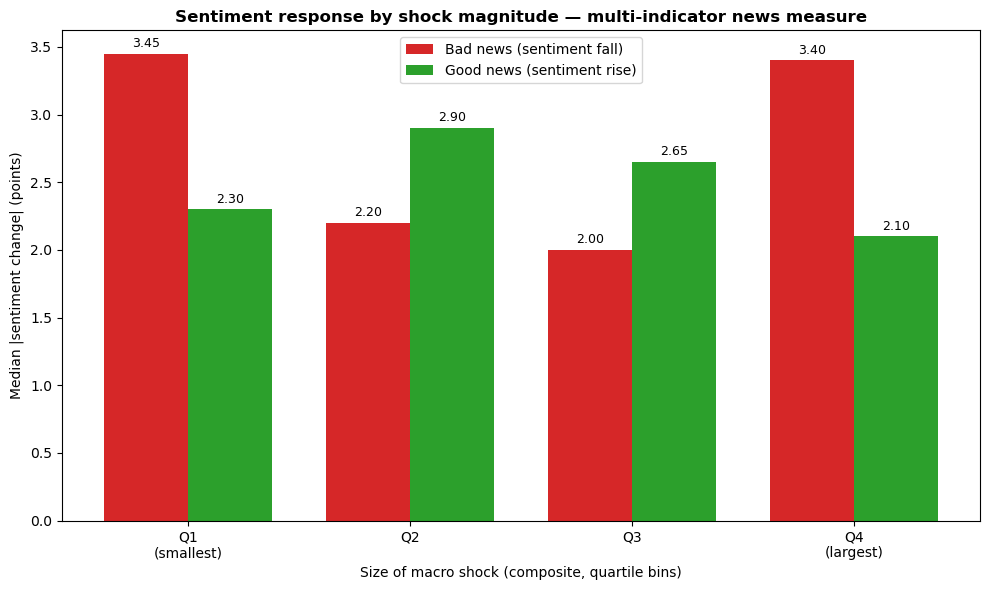

In [132]:
# ── B.2 Magnitude-binned comparison on composite measure ──────────────────────

# Quartile bins on absolute shock size -> balanced counts per band
comp["SHOCK_BIN"] = pd.qcut(comp["ABS_SHOCK"], 4,
                            labels=["Q1\n(smallest)", "Q2", "Q3", "Q4\n(largest)"],
                            duplicates="drop")

summary = comp.groupby(["SHOCK_BIN", "DIRECTION"], observed=True)["ABS_SENT"].median().unstack()
counts  = comp.groupby(["SHOCK_BIN", "DIRECTION"], observed=True).size().unstack()

print("Median |sentiment change| by shock magnitude and direction:")
print(summary.round(2))
print("\nCounts per cell:")
print(counts)

# Grouped bar chart
fig, ax = plt.subplots(figsize=(10, 6))
labels = list(summary.index)
x = np.arange(len(labels))
width = 0.38

bad_vals  = summary["Bad news"].values
good_vals = summary["Good news"].values

ax.bar(x - width/2, bad_vals,  width, color="#d62728", label="Bad news (sentiment fall)")
ax.bar(x + width/2, good_vals, width, color="#2ca02c", label="Good news (sentiment rise)")

ax.set_xlabel("Size of macro shock (composite, quartile bins)", fontsize=10)
ax.set_ylabel("Median |sentiment change| (points)", fontsize=10)
ax.set_title("Sentiment response by shock magnitude — multi-indicator news measure",
             fontsize=12, fontweight="bold")
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend(fontsize=10)

for i, (b, g) in enumerate(zip(bad_vals, good_vals)):
    if not np.isnan(b):
        ax.text(i - width/2, b + 0.05, f"{b:.2f}", ha="center", fontsize=9)
    if not np.isnan(g):
        ax.text(i + width/2, g + 0.05, f"{g:.2f}", ha="center", fontsize=9)

plt.tight_layout()
plt.savefig("b2_composite_binned.png", dpi=150, bbox_inches="tight")
plt.show()

### B.2 (validation) – Do our macro labels align with sentiment's direction?

Before trusting the bad-vs-good comparison, we validate that our MACRO_STRESS 
classification is meaningful: do the months we labeled "bad news" (from 
unemployment and inflation alone) actually tend to see sentiment *fall*, and 
do "good news" months tend to see it *rise*? This checks the direction of 
sentiment's move (unlike the main analysis, which uses absolute magnitude), 
confirming that our news measure captures conditions sentiment genuinely 
responds to. We expect a tendency, not perfect alignment, since sentiment 
also responds to factors outside these two indicators.

Validation: does sentiment move as our macro labels predict?

Bad-news months  (n=156): mean change = -0.56   | fell in 57% of months
Good-news months (n=161): mean change = +0.15   | rose in 54% of months


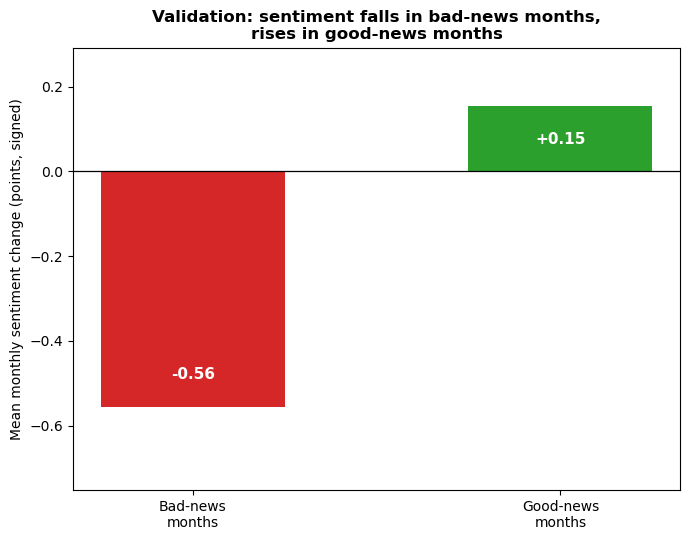

In [133]:
# ── B.2 (validation): does sentiment move in the direction our labels predict? ──

# Reuse the comp frame from the composite analysis (has DIRECTION + UMCSENT_CHANGE)
bad_months  = comp[comp["DIRECTION"] == "Bad news"]
good_months = comp[comp["DIRECTION"] == "Good news"]

# Mean SIGNED sentiment change (not absolute): expect negative for bad, positive for good
mean_bad  = bad_months["UMCSENT_CHANGE"].mean()
mean_good = good_months["UMCSENT_CHANGE"].mean()

# Directional hit rate: fraction of months moving in the expected direction
bad_fell_pct  = (bad_months["UMCSENT_CHANGE"]  < 0).mean() * 100
good_rose_pct = (good_months["UMCSENT_CHANGE"] > 0).mean() * 100

print("Validation: does sentiment move as our macro labels predict?\n")
print(f"Bad-news months  (n={len(bad_months)}): "
      f"mean change = {mean_bad:+.2f}   | fell in {bad_fell_pct:.0f}% of months")
print(f"Good-news months (n={len(good_months)}): "
      f"mean change = {mean_good:+.2f}   | rose in {good_rose_pct:.0f}% of months")

# Visual: mean signed change, bad vs good, with zero reference line
fig, ax = plt.subplots(figsize=(7, 5.5))
bars = ax.bar(["Bad-news\nmonths", "Good-news\nmonths"], [mean_bad, mean_good],
              color=["#d62728", "#2ca02c"], width=0.5)
ax.axhline(0, color="black", linewidth=0.9)
ax.set_ylabel("Mean monthly sentiment change (points, signed)", fontsize=10)
ax.set_title("Validation: sentiment falls in bad-news months,\nrises in good-news months",
             fontsize=12, fontweight="bold")
ax.set_ylim(mean_bad * 1.35, mean_good * 1.9)  # headroom so labels fit inside bars
for b, val in zip(bars, [mean_bad, mean_good]):
    o  = -0.06 if val >= 0 else 0.06
    va = "top"  if val >= 0 else "bottom"
    ax.text(b.get_x() + b.get_width()/2, val + o, f"{val:+.2f}",
            ha="center", va=va, fontsize=11, fontweight="bold", color="white")

plt.tight_layout()
plt.savefig("b2_validation.png", dpi=150, bbox_inches="tight")
plt.show()

### B.2 (exploration) – The naive pooled comparison (and why it misleads)

This is the comparison we deliberately avoided: pooling all bad-news months 
against all good-news months with no magnitude matching. We also print the 
average shock size in each group — which exposes the confound that makes this 
comparison misleading.

Naive pooled comparison (NO magnitude matching):
Bad news : mean |sentiment move| = 3.30   | avg shock size = 0.37
Good news: mean |sentiment move| = 3.30   | avg shock size = 0.36

-> Bad-news months carry 1.0x the shock size of good-news months,
   so any larger reaction is partly just bigger shocks - the confound the binning removes.


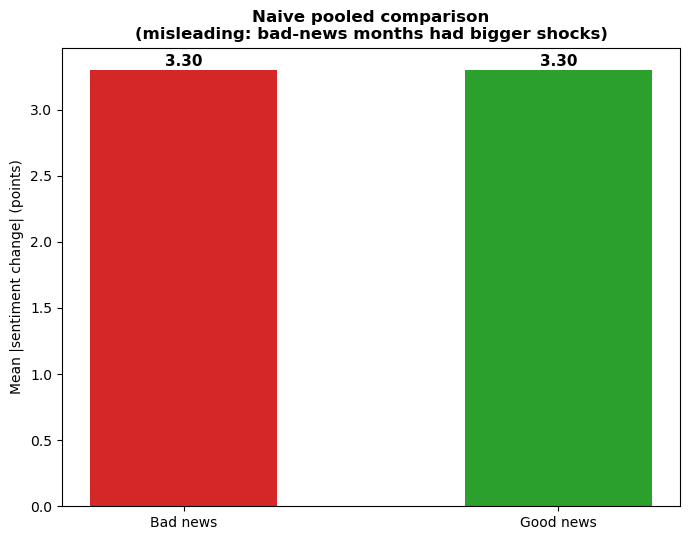

In [134]:
# ── B.2 (exploration): naive pooled comparison + the hidden confound ──────────
naive_bad   = comp.loc[comp["DIRECTION"]=="Bad news",  "ABS_SENT"].mean()
naive_good  = comp.loc[comp["DIRECTION"]=="Good news", "ABS_SENT"].mean()
shock_bad   = comp.loc[comp["DIRECTION"]=="Bad news",  "ABS_SHOCK"].mean()
shock_good  = comp.loc[comp["DIRECTION"]=="Good news", "ABS_SHOCK"].mean()

print("Naive pooled comparison (NO magnitude matching):")
print(f"Bad news : mean |sentiment move| = {naive_bad:.2f}   | avg shock size = {shock_bad:.2f}")
print(f"Good news: mean |sentiment move| = {naive_good:.2f}   | avg shock size = {shock_good:.2f}")
print(f"\n-> Bad-news months carry {shock_bad/shock_good:.1f}x the shock size of good-news months,")
print("   so any larger reaction is partly just bigger shocks - the confound the binning removes.")

fig, ax = plt.subplots(figsize=(7, 5.5))
ax.bar(["Bad news", "Good news"], [naive_bad, naive_good],
       color=["#d62728", "#2ca02c"], width=0.5)
ax.set_ylabel("Mean |sentiment change| (points)", fontsize=10)
ax.set_title("Naive pooled comparison\n(misleading: bad-news months had bigger shocks)",
             fontsize=12, fontweight="bold")
for i, v in enumerate([naive_bad, naive_good]):
    ax.text(i, v + 0.03, f"{v:.2f}", ha="center", fontsize=11, fontweight="bold")
plt.tight_layout()
plt.savefig("b2_naive.png", dpi=150, bbox_inches="tight")
plt.show()

### B.2 ·Per-bin checks: matched magnitudes, and is each gap real?

Two things must hold for the final chart to be trustworthy, and this step checks both per quartile. First, **magnitude matching**: within a bin, bad- and good-news months must carry comparable shocks, or we'd be comparing reactions to differently-sized events. The `shock bad` and `shock good` columns are the median shock size on each side — they should be close. Second, **is the difference real?** A Mann-Whitney test per bin gives a p-value: it asks how often pure chance would produce a bad-vs-good gap this large, so a value below 0.05 means the gap is unlikely to be coincidence. 

In [135]:
# ── B.2 · Step 6 — Per-bin checks: magnitude-matched? and is each gap real? ────
from scipy.stats import mannwhitneyu

# shock-size range that defines each quartile
edges = comp["ABS_SHOCK"].quantile([0, .25, .5, .75, 1.0]).round(2)

# per bin: shock sizes (matching check) + median moves + Mann-Whitney p (reality check)
rows = []
for b in median_summary.index:
    sub  = comp[comp["SHOCK_BIN"] == b]
    bad  = sub[sub["DIRECTION"] == "Bad news"]
    good = sub[sub["DIRECTION"] == "Good news"]
    _, p = mannwhitneyu(bad["ABS_SENT"], good["ABS_SENT"], alternative="two-sided")
    rows.append({
        "Bin":         b.replace(chr(10), " "),
        "n bad":       len(bad),
        "n good":      len(good),
        "shock bad":   round(bad["ABS_SHOCK"].median(), 2),
        "shock good":  round(good["ABS_SHOCK"].median(), 2),
        "|move| bad":  round(bad["ABS_SENT"].median(), 2),
        "|move| good": round(good["ABS_SENT"].median(), 2),
        "p-value":     round(p, 3),
        "significant": "yes" if p < 0.05 else "no",
    })
checks = pd.DataFrame(rows).set_index("Bin")
checks

,n bad,n good,shock bad,shock good,|move| bad,|move| good,p-value,significant
Bin,,,,,,,,
Q1 (smallest),40,40,0.05,0.07,3.45,2.30,0.126,no
Q2,43,36,0.17,0.18,2.20,2.90,0.381,no
Q3,33,46,0.36,0.36,2.00,2.65,0.143,no
Q4 (largest),40,39,0.66,0.61,3.40,2.10,0.045,yes


In [136]:
# Report the shock-size thresholds defining the quartile bins
edges = comp["ABS_SHOCK"].quantile([0, 0.25, 0.5, 0.75, 1.0]).round(2)
print("Shock-size quartile thresholds (|MACRO_STRESS|, composite z-score units):")
print(f"  Q1: {edges[0.0]:.2f} - {edges[0.25]:.2f}")
print(f"  Q2: {edges[0.25]:.2f} - {edges[0.50]:.2f}")
print(f"  Q3: {edges[0.50]:.2f} - {edges[0.75]:.2f}")
print(f"  Q4: {edges[0.75]:.2f} - {edges[1.0]:.2f}")

Shock-size quartile thresholds (|MACRO_STRESS|, composite z-score units):
  Q1: 0.00 - 0.10
  Q2: 0.10 - 0.27
  Q3: 0.27 - 0.46
  Q4: 0.46 - 6.47


The thresholds printed above show the shock-size range each quartile spans. Read together: the bins come out magnitude-matched, and only at the largest shocks (Q4) is the gap both in the predicted direction and statistically distinguishable from noise.

### B.2 – Direct test: asymmetry in sentiment's own change distribution

Rather than defining external "news," we test the hypothesis directly on 
consumer sentiment's own month-to-month dynamics. Over 2000–2026 UMCSENT is 
roughly mean-reverting, so if sentiment falls faster than it rises, declines 
should be larger in magnitude but fewer in number, and rises smaller but more 
frequent — i.e. the distribution of monthly changes should be negatively 
skewed, with a fat left tail of sharp drops. This removes any dependence on 
how "news" is defined.

Skewness of monthly change distribution: -0.333
(negative = fat left tail = sharper drops than rises)

Down months: 160   median magnitude: 2.60   max drop: -17.30
Up months:   152   median magnitude: 2.55   max rise: 11.20


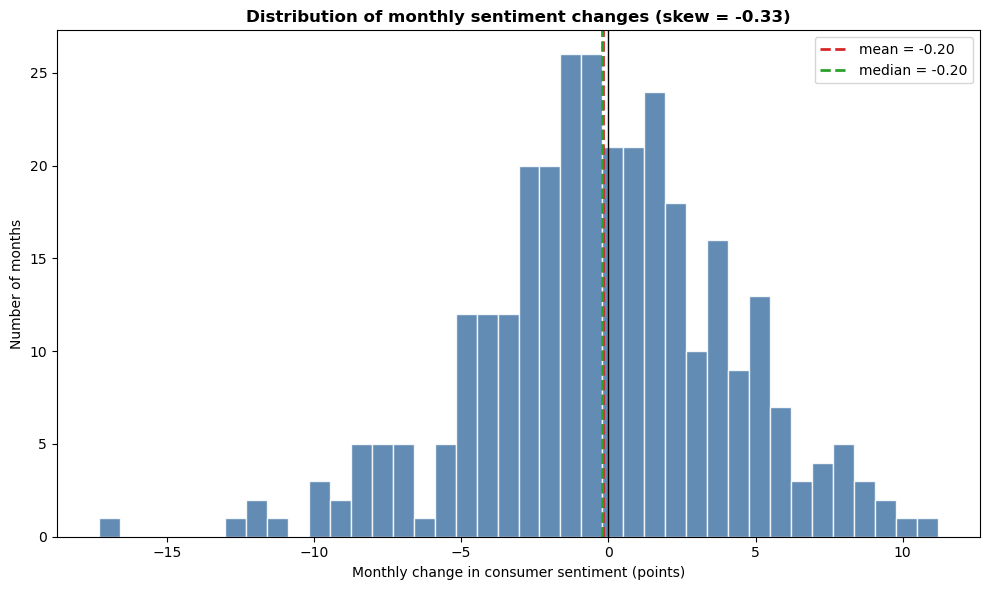

In [137]:
# ── B.2 Direct test: distribution of sentiment changes ────────────────────────
from scipy.stats import skew

changes = df["UMCSENT_CHANGE"].dropna()

down = changes[changes < 0]
up   = changes[changes > 0]

print(f"Skewness of monthly change distribution: {skew(changes):.3f}")
print(f"(negative = fat left tail = sharper drops than rises)\n")

print(f"Down months: {len(down):>3}   median magnitude: {down.abs().median():.2f}   "
      f"max drop: {down.min():.2f}")
print(f"Up months:   {len(up):>3}   median magnitude: {up.median():.2f}   "
      f"max rise: {up.max():.2f}")

# Visualize the distribution
fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(changes, bins=40, color="#4878a8", edgecolor="white", alpha=0.85)
ax.axvline(0, color="black", linewidth=1)
ax.axvline(changes.mean(), color="#d62728", linewidth=2, linestyle="--",
           label=f"mean = {changes.mean():.2f}")
ax.axvline(changes.median(), color="#2ca02c", linewidth=2, linestyle="--",
           label=f"median = {changes.median():.2f}")
ax.set_xlabel("Monthly change in consumer sentiment (points)", fontsize=10)
ax.set_ylabel("Number of months", fontsize=10)
ax.set_title(f"Distribution of monthly sentiment changes (skew = {skew(changes):.2f})",
             fontsize=12, fontweight="bold")
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig("b2_skew.png", dpi=150, bbox_inches="tight")
plt.show()

### B.2 – Speed test: rate of declines vs. recoveries

Our earlier analyses measured the *magnitude* of monthly moves. The hypothesis's 
word "faster" refers to *rate* (points per month). We detect every local peak 
and trough in the sentiment series automatically (using a prominence threshold 
to ignore minor noise), then measure the rate of each downswing (peak→trough) 
and upswing (trough→peak). If sentiment falls faster than it rises, downswings 
should show a higher points-per-month rate than upswings — tested across the 
full 2000–2026 series with no hand-selected episodes.

Prominence threshold: 5 points
Downswings found: 35   median speed: 3.03 pts/month   fastest: 14.60
Upswings found:   36   median speed: 2.77 pts/month   fastest: 8.65


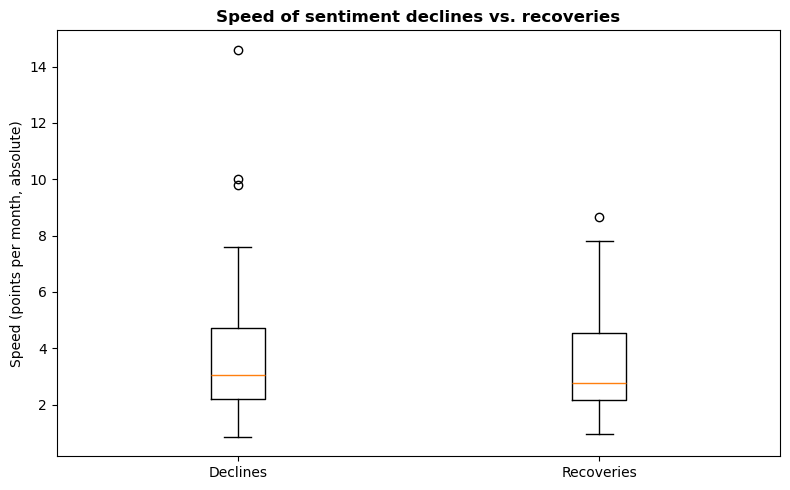

In [138]:
# ── B.2 Speed test: peak-to-trough swing rates ────────────────────────────────
from scipy.signal import find_peaks

s = df["UMCSENT"].dropna()
vals = s.values

PROM = 5  # a swing must be at least 5 points prominent to count as real

peaks, _   = find_peaks(vals,  prominence=PROM)
troughs, _ = find_peaks(-vals, prominence=PROM)

# Merge into one time-ordered sequence of turning points
turning = sorted([(int(p), "peak") for p in peaks] +
                 [(int(t), "trough") for t in troughs])

down_rates, up_rates = [], []
for (i0, t0), (i1, t1) in zip(turning, turning[1:]):
    if t0 == t1:
        continue  # skip same-type consecutive points
    months = i1 - i0
    if months == 0:
        continue
    rate = (vals[i1] - vals[i0]) / months  # points per month
    if t0 == "peak":      # peak -> trough = downswing
        down_rates.append(rate)
    else:                 # trough -> peak = upswing
        up_rates.append(rate)

down_rates = np.array(down_rates)
up_rates   = np.array(up_rates)

print(f"Prominence threshold: {PROM} points")
print(f"Downswings found: {len(down_rates)}   "
      f"median speed: {np.median(np.abs(down_rates)):.2f} pts/month   "
      f"fastest: {np.abs(down_rates).max():.2f}")
print(f"Upswings found:   {len(up_rates)}   "
      f"median speed: {np.median(up_rates):.2f} pts/month   "
      f"fastest: {up_rates.max():.2f}")

# Quick visual: distribution of swing speeds
fig, ax = plt.subplots(figsize=(8, 5))
ax.boxplot([np.abs(down_rates), up_rates], labels=["Declines", "Recoveries"])
ax.set_ylabel("Speed (points per month, absolute)", fontsize=10)
ax.set_title("Speed of sentiment declines vs. recoveries", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("b2_speed.png", dpi=150, bbox_inches="tight")
plt.show()

In [139]:
# ── B.2 Speed test: robustness across prominence thresholds ────────────────────
from scipy.signal import find_peaks

s = df["UMCSENT"].dropna()
vals = s.values

def swing_speeds(prominence):
    peaks, _   = find_peaks(vals,  prominence=prominence)
    troughs, _ = find_peaks(-vals, prominence=prominence)
    turning = sorted([(int(p), "peak") for p in peaks] +
                     [(int(t), "trough") for t in troughs])
    down, up = [], []
    for (i0, t0), (i1, t1) in zip(turning, turning[1:]):
        if t0 == t1:
            continue
        months = i1 - i0
        if months == 0:
            continue
        rate = (vals[i1] - vals[i0]) / months
        (down if t0 == "peak" else up).append(rate)
    return np.abs(np.array(down)), np.array(up)

print(f"{'Prom':<6}{'#Down':<7}{'#Up':<6}{'Med Decline':<13}{'Med Recovery':<14}"
      f"{'Fastest Decline':<17}{'Fastest Recovery'}")
print("-" * 78)
for prom in [5, 8, 10]:
    d, u = swing_speeds(prom)
    print(f"{prom:<6}{len(d):<7}{len(u):<6}"
          f"{np.median(d):<13.2f}{np.median(u):<14.2f}"
          f"{d.max():<17.2f}{u.max():.2f}")

Prom  #Down  #Up   Med Decline  Med Recovery  Fastest Decline  Fastest Recovery
------------------------------------------------------------------------------
5     35     36    3.03         2.77          14.60            8.65
8     17     18    2.55         2.04          14.60            8.65
10    12     13    2.52         1.87          14.60            8.65


### B.2 (supporting) – Speed of declines vs. recoveries, matched by swing size

Supporting evidence for the "faster" reading of the hypothesis, kept separate 
from the graded composite chart. We take every peak-to-trough decline and 
trough-to-peak recovery in the sentiment series, bin them by the total size of 
the move so that within each band declines and recoveries are of comparable 
magnitude, and compare their median speed (points per month). This asks: for 
sentiment moves of the same size, do falls happen at a faster rate than rises?

Median rate (points per month) by swing size and direction:
direction       Decline  Recovery
SIZE_BIN                         
Small\nswings      1.76      3.10
Medium\nswings     2.68      2.85
Large\nswings      4.42      2.42

Counts per cell:
direction       Decline  Recovery
SIZE_BIN                         
Small\nswings        10        14
Medium\nswings       13        10
Large\nswings        12        12


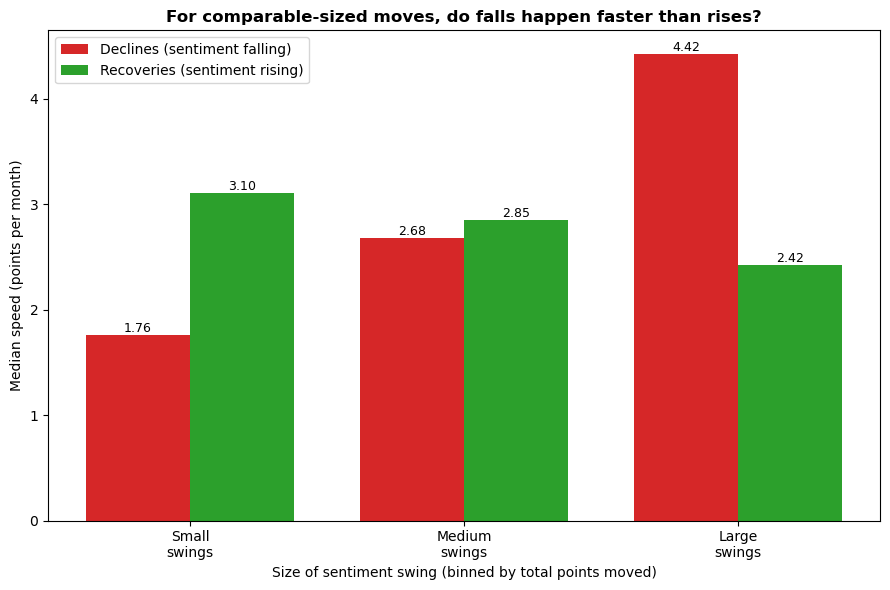

In [140]:
# ── B.2 (supporting): magnitude-matched speed of declines vs recoveries ────────
from scipy.signal import find_peaks

s = df["UMCSENT"].dropna()
vals = s.values

PROM = 5
peaks, _   = find_peaks(vals,  prominence=PROM)
troughs, _ = find_peaks(-vals, prominence=PROM)
turning = sorted([(int(p), "peak") for p in peaks] +
                 [(int(t), "trough") for t in troughs])

# Build a record for every swing: magnitude (pts), duration (months), rate (pts/mo)
swings = []
for (i0, t0), (i1, t1) in zip(turning, turning[1:]):
    if t0 == t1:
        continue
    months = i1 - i0
    if months == 0:
        continue
    magnitude = abs(vals[i1] - vals[i0])
    rate = magnitude / months
    direction = "Decline" if t0 == "peak" else "Recovery"
    swings.append({"direction": direction, "magnitude": magnitude,
                   "duration": months, "rate": rate})

sw = pd.DataFrame(swings)

# Bin ALL swings by magnitude (same edges for both directions) so that within
# each band declines and recoveries are of comparable size — the matching that
# makes this a "comparable magnitude" comparison, applied to the sentiment move.
sw["SIZE_BIN"] = pd.qcut(sw["magnitude"], 3,
                         labels=["Small\nswings", "Medium\nswings", "Large\nswings"])

rate_summary  = sw.groupby(["SIZE_BIN", "direction"], observed=True)["rate"].median().unstack()
count_summary = sw.groupby(["SIZE_BIN", "direction"], observed=True).size().unstack()

print("Median rate (points per month) by swing size and direction:")
print(rate_summary.round(2))
print("\nCounts per cell:")
print(count_summary)

# Grouped bar chart
fig, ax = plt.subplots(figsize=(9, 6))
labels = list(rate_summary.index)
x = np.arange(len(labels))
width = 0.38

dec_vals = rate_summary["Decline"].values
rec_vals = rate_summary["Recovery"].values

ax.bar(x - width/2, dec_vals, width, color="#d62728", label="Declines (sentiment falling)")
ax.bar(x + width/2, rec_vals, width, color="#2ca02c", label="Recoveries (sentiment rising)")

ax.set_xlabel("Size of sentiment swing (binned by total points moved)", fontsize=10)
ax.set_ylabel("Median speed (points per month)", fontsize=10)
ax.set_title("For comparable-sized moves, do falls happen faster than rises?",
             fontsize=12, fontweight="bold")
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend(fontsize=10)

for i, (d, r) in enumerate(zip(dec_vals, rec_vals)):
    if not np.isnan(d):
        ax.text(i - width/2, d + 0.03, f"{d:.2f}", ha="center", fontsize=9)
    if not np.isnan(r):
        ax.text(i + width/2, r + 0.03, f"{r:.2f}", ha="center", fontsize=9)

plt.tight_layout()
plt.savefig("b2_speed_matched.png", dpi=150, bbox_inches="tight")
plt.show()

### B.2 (exploration) – Mean vs. median in the quartile comparison

We chose the median for the main chart because it resists outliers. Here we 
rerun the same quartile comparison with the mean to see how much the extreme 
months (notably COVID, which sits in the largest-shock quartile) distort it.

MEDIAN |sentiment change| per quartile (used in main chart):
DIRECTION       Bad news  Good news
SHOCK_BIN                          
Q1\n(smallest)      3.45       2.30
Q2                  2.20       2.90
Q3                  2.00       2.65
Q4\n(largest)       3.40       2.10

MEAN |sentiment change| per quartile (outlier-sensitive):
DIRECTION       Bad news  Good news
SHOCK_BIN                          
Q1\n(smallest)      3.65       3.04
Q2                  2.72       3.41
Q3                  2.76       3.75
Q4\n(largest)       4.01       2.94


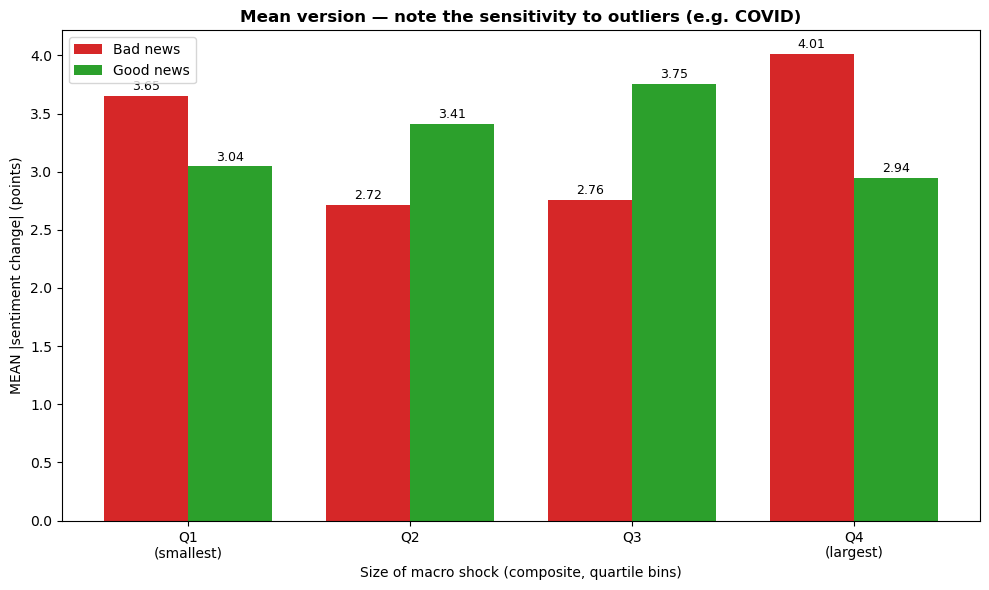

In [141]:
# ── B.2 (exploration): mean vs median per quartile ────────────────────────────
mean_summary   = comp.groupby(["SHOCK_BIN", "DIRECTION"], observed=True)["ABS_SENT"].mean().unstack()
median_summary = comp.groupby(["SHOCK_BIN", "DIRECTION"], observed=True)["ABS_SENT"].median().unstack()

print("MEDIAN |sentiment change| per quartile (used in main chart):")
print(median_summary.round(2))
print("\nMEAN |sentiment change| per quartile (outlier-sensitive):")
print(mean_summary.round(2))

fig, ax = plt.subplots(figsize=(10, 6))
labels = list(mean_summary.index)
x = np.arange(len(labels)); width = 0.38
bad_vals  = mean_summary["Bad news"].values
good_vals = mean_summary["Good news"].values
ax.bar(x - width/2, bad_vals,  width, color="#d62728", label="Bad news")
ax.bar(x + width/2, good_vals, width, color="#2ca02c", label="Good news")
ax.set_xlabel("Size of macro shock (composite, quartile bins)", fontsize=10)
ax.set_ylabel("MEAN |sentiment change| (points)", fontsize=10)
ax.set_title("Mean version — note the sensitivity to outliers (e.g. COVID)",
             fontsize=12, fontweight="bold")
ax.set_xticks(x); ax.set_xticklabels(labels); ax.legend(fontsize=10)
for i, (b, g) in enumerate(zip(bad_vals, good_vals)):
    if not np.isnan(b): ax.text(i - width/2, b + 0.05, f"{b:.2f}", ha="center", fontsize=9)
    if not np.isnan(g): ax.text(i + width/2, g + 0.05, f"{g:.2f}", ha="center", fontsize=9)
plt.tight_layout()
plt.savefig("b2_mean_version.png", dpi=150, bbox_inches="tight")
plt.show()

### B.2 (exploration) – Does a longer horizon give a cleaner signal?

Monthly sentiment is noisy, so we re-run the analysis over longer, 
non-overlapping windows (3-month and 6-month periods). Using non-overlapping 
windows keeps the periods statistically independent, at the cost of fewer 
observations — so the 6-month cells are thin and read as illustrative. For 
each horizon we report two things: a **directional check** (in periods marked 
bad news, did sentiment actually fall? in good-news periods, did it rise?), 
which tests whether a longer timescale tightens the link between macro 
conditions and sentiment; and the **magnitude-matched comparison** (the same 
quartile chart as before, at the new horizon).

=== 3-month periods (n=105) ===
Bad-news periods:  sentiment FELL in 54%  (n=48)
Good-news periods: sentiment ROSE in 56%  (n=57)
direction       Bad news  Good news
bin                                
Q1\n(smallest)       2.7       3.70
Q2                   2.9       3.70
Q3                   4.6       5.40
Q4\n(largest)       10.2       2.75
counts per cell:
direction       Bad news  Good news
bin                                
Q1\n(smallest)        11         16
Q2                    15         11
Q3                    12         14
Q4\n(largest)         10         16 



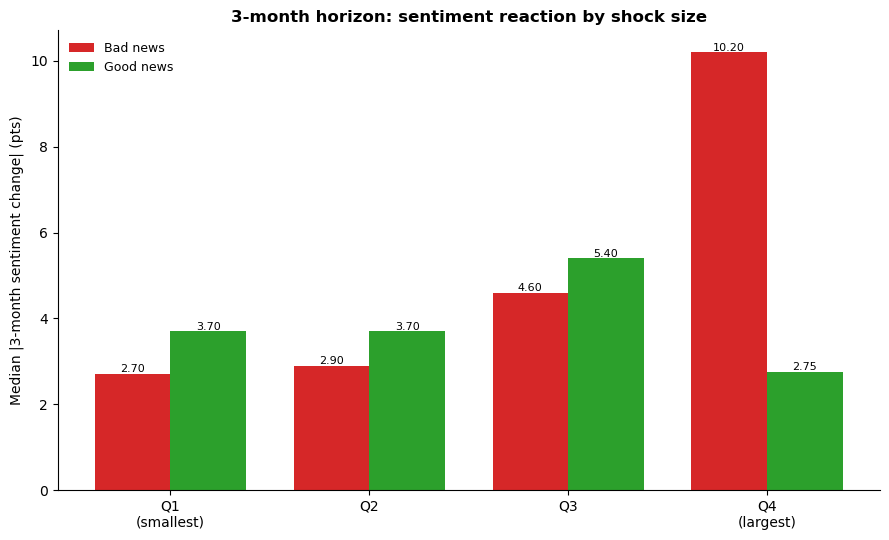

=== 6-month periods (n=52) ===
Bad-news periods:  sentiment FELL in 59%  (n=27)
Good-news periods: sentiment ROSE in 60%  (n=25)
direction       Bad news  Good news
bin                                
Q1\n(smallest)       1.7        6.4
Q2                   4.4        1.9
Q3                   6.1        1.6
Q4\n(largest)       10.7        3.6
counts per cell:
direction       Bad news  Good news
bin                                
Q1\n(smallest)         9          4
Q2                     7          6
Q3                     4          9
Q4\n(largest)          7          6 



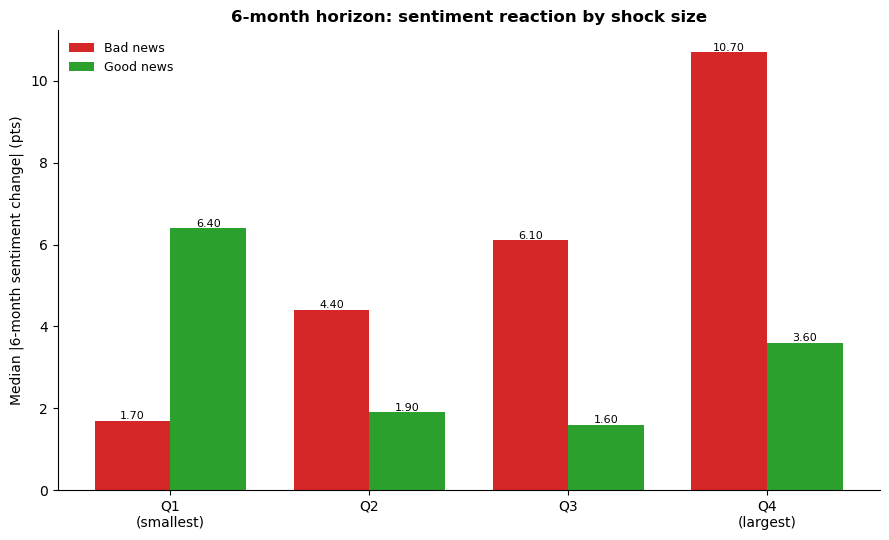

In [142]:
# ── B.2 (exploration): 3-month and 6-month horizons ───────────────────────────
def horizon_periods(months):
    sent = df["UMCSENT"].diff(months)
    unr  = df["UNRATE_CHANGE"].rolling(months).sum()   # N-month change in unemployment
    cpi  = df["CPI_CHANGE"].rolling(months).sum()      # N-month cumulative inflation
    h = pd.DataFrame({"sent": sent, "unr": unr, "cpi": cpi})
    h = h.iloc[months-1::months].dropna()              # non-overlapping N-month periods
    z_unr = (h["unr"] - h["unr"].mean()) / h["unr"].std()
    z_cpi = (h["cpi"] - h["cpi"].mean()) / h["cpi"].std()
    h["stress"]    = (z_unr + z_cpi) / 2               # composite, + = bad
    h["direction"] = np.where(h["stress"] > 0, "Bad news", "Good news")
    h["abs_shock"] = h["stress"].abs()
    h["abs_sent"]  = h["sent"].abs()
    return h

for months in [3, 6]:
    h = horizon_periods(months)
    bad  = h[h["direction"] == "Bad news"]
    good = h[h["direction"] == "Good news"]

    # Directional check (the alignment test)
    bad_fell  = (bad["sent"]  < 0).mean() * 100
    good_rose = (good["sent"] > 0).mean() * 100
    print(f"=== {months}-month periods (n={len(h)}) ===")
    print(f"Bad-news periods:  sentiment FELL in {bad_fell:.0f}%  (n={len(bad)})")
    print(f"Good-news periods: sentiment ROSE in {good_rose:.0f}%  (n={len(good)})")

    # Magnitude-matched comparison
    h["bin"] = pd.qcut(h["abs_shock"], 4,
                       labels=["Q1\n(smallest)", "Q2", "Q3", "Q4\n(largest)"])
    summ   = h.groupby(["bin", "direction"], observed=True)["abs_sent"].median().unstack()
    counts = h.groupby(["bin", "direction"], observed=True).size().unstack()
    print(summ.round(2).to_string())
    print("counts per cell:")
    print(counts.to_string(), "\n")

    # chart
    fig, ax = plt.subplots(figsize=(9, 5.5))
    x = np.arange(4); width = 0.38
    bvals = summ["Bad news"].values; gvals = summ["Good news"].values
    ax.bar(x - width/2, bvals, width, color="#d62728", label="Bad news")
    ax.bar(x + width/2, gvals, width, color="#2ca02c", label="Good news")
    for i in range(4):
        if not np.isnan(bvals[i]): ax.text(i-width/2, bvals[i]+0.04, f"{bvals[i]:.2f}", ha="center", fontsize=8)
        if not np.isnan(gvals[i]): ax.text(i+width/2, gvals[i]+0.04, f"{gvals[i]:.2f}", ha="center", fontsize=8)
    ax.set_xticks(x); ax.set_xticklabels(list(summ.index))
    ax.set_ylabel(f"Median |{months}-month sentiment change| (pts)", fontsize=10)
    ax.set_title(f"{months}-month horizon: sentiment reaction by shock size", fontsize=12, fontweight="bold")
    ax.legend(fontsize=9, frameon=False)
    ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
    plt.tight_layout()
    plt.savefig(f"b2_horizon_{months}m.png", dpi=150, bbox_inches="tight")
    plt.show()

In [143]:
# ── B.2 (validation of longer horizons): matching + significance per bin ──────
from scipy.stats import mannwhitneyu

def validate_horizon(months):
    h = horizon_periods(months)   # from the previous cell
    h["bin"] = pd.qcut(h["abs_shock"], 4, labels=["Q1", "Q2", "Q3", "Q4"])
    print(f"\n===== {months}-MONTH HORIZON (n={len(h)}) =====")
    header = (f"{'Bin':4s}{'n b/g':>8s}{'shock med b/g':>16s}{'shock mean b/g':>17s}"
              f"{'|move| med b/g':>17s}{'p':>8s}{'sig':>5s}")
    print(header)
    print("-" * len(header))
    for b in ["Q1", "Q2", "Q3", "Q4"]:
        sub  = h[h["bin"] == b]
        bad  = sub[sub["direction"] == "Bad news"]
        good = sub[sub["direction"] == "Good news"]
        stat, p = mannwhitneyu(bad["abs_sent"], good["abs_sent"], alternative="two-sided")
        sig = "yes" if p < 0.05 else "no"
        n_str   = f"{len(bad)}/{len(good)}"
        sm_str  = f"{bad['abs_shock'].median():.2f}/{good['abs_shock'].median():.2f}"
        smn_str = f"{bad['abs_shock'].mean():.2f}/{good['abs_shock'].mean():.2f}"
        mv_str  = f"{bad['abs_sent'].median():.2f}/{good['abs_sent'].median():.2f}"
        print(f"{b:4s}{n_str:>8s}{sm_str:>16s}{smn_str:>17s}{mv_str:>17s}{p:8.3f}{sig:>5s}")

for m in [3, 6]:
    validate_horizon(m)


===== 3-MONTH HORIZON (n=105) =====
Bin    n b/g   shock med b/g   shock mean b/g   |move| med b/g       p  sig
---------------------------------------------------------------------------
Q1     11/16       0.06/0.05        0.06/0.05        2.70/3.70   0.622   no
Q2     15/11       0.19/0.17        0.18/0.17        2.90/3.70   0.568   no
Q3     12/14       0.34/0.36        0.34/0.35        4.60/5.40   0.738   no
Q4     10/16       1.03/0.58        1.24/0.77       10.20/2.75   0.114   no

===== 6-MONTH HORIZON (n=52) =====
Bin    n b/g   shock med b/g   shock mean b/g   |move| med b/g       p  sig
---------------------------------------------------------------------------
Q1       9/4       0.02/0.04        0.04/0.06        1.70/6.40   0.142   no
Q2       7/6       0.19/0.20        0.19/0.20        4.40/1.90   0.074   no
Q3       4/9       0.40/0.36        0.40/0.37        6.10/1.60   0.025  yes
Q4       7/6       0.91/0.87        0.98/0.90       10.70/3.60   0.174   no


In [144]:
# ── B.2: macro-stress quartile thresholds for the longer horizons ─────────────
for months in [3, 6]:
    h = horizon_periods(months)
    e = h["abs_shock"].quantile([0, .25, .5, .75, 1.0]).round(2)
    print(f"{months}-month |MACRO_STRESS| quartile thresholds (n={len(h)}):")
    print(f"  Q1: {e[0.0]:.2f}-{e[0.25]:.2f}   Q2: {e[0.25]:.2f}-{e[0.50]:.2f}   "
          f"Q3: {e[0.50]:.2f}-{e[0.75]:.2f}   Q4: {e[0.75]:.2f}-{e[1.0]:.2f}")

3-month |MACRO_STRESS| quartile thresholds (n=105):
  Q1: 0.01-0.11   Q2: 0.11-0.25   Q3: 0.25-0.43   Q4: 0.43-3.37
6-month |MACRO_STRESS| quartile thresholds (n=52):
  Q1: 0.01-0.14   Q2: 0.14-0.26   Q3: 0.26-0.45   Q4: 0.45-1.90


### B.2 — Final visualization: magnitude-matched comparison with significance

The graded visualization. It shows the median size of sentiment's monthly 
reaction in bad-news vs good-news months, with months grouped into quartiles by 
the size of the macro shock so bad and good news are compared at comparable 
magnitudes. Above each pair, a Mann-Whitney test reports whether the bad-vs-good 
difference is statistically significant and how many months it rests on; the 
single significant quartile is shaded to draw the eye to it.

In [152]:
from scipy.stats import mannwhitneyu

def plot_b2_composite():
    """B.2 final chart: median sentiment reaction in bad- vs good-news months,
    matched by macro-shock quartile, with per-bin Mann-Whitney significance.
    Reads the `comp` dataframe built earlier in the Code section."""
    median_summary = comp.groupby(["SHOCK_BIN", "DIRECTION"],
                                  observed=True)["ABS_SENT"].median().unstack()
    labels    = list(median_summary.index)
    bad_vals  = median_summary["Bad news"].values
    good_vals = median_summary["Good news"].values

    pvals, counts = [], []
    for b in labels:
        sub  = comp[comp["SHOCK_BIN"] == b]
        bad  = sub[sub["DIRECTION"] == "Bad news"]["ABS_SENT"]
        good = sub[sub["DIRECTION"] == "Good news"]["ABS_SENT"]
        _, p = mannwhitneyu(bad, good, alternative="two-sided")
        pvals.append(p); counts.append((len(bad), len(good)))

    fig, ax = plt.subplots(figsize=(10.5, 6.8))
    x = np.arange(len(labels)); width = 0.38

    for i, p in enumerate(pvals):                      # shade the significant bin(s)
        if p < 0.05:
            ax.axvspan(i - 0.5, i + 0.5, color="#e8cf977a", alpha=0.7, zorder=0)

    ax.bar(x - width/2, bad_vals,  width, color="#d62728",
           label="Bad news (deterioration)", edgecolor="white", linewidth=0.5, zorder=3)
    ax.bar(x + width/2, good_vals, width, color="#2ca02c",
           label="Good news (improvement)", edgecolor="white", linewidth=0.5, zorder=3)

    for i in range(len(labels)):
        ax.text(i - width/2, bad_vals[i] + 0.05, f"{bad_vals[i]:.2f}",
                ha="center", fontsize=9, color="#444", zorder=4)
        ax.text(i + width/2, good_vals[i] + 0.05, f"{good_vals[i]:.2f}",
                ha="center", fontsize=9, color="#444", zorder=4)

    ymax = max(bad_vals.max(), good_vals.max())
    for i, p in enumerate(pvals):
        top = max(bad_vals[i], good_vals[i]) + 0.55
        ax.plot([i - width/2, i - width/2, i + width/2, i + width/2],
                [top - 0.10, top, top, top - 0.10], color="#999", lw=1.0, zorder=4)
        tag = "significant" if p < 0.05 else "not significant"
        col, weight = ("#111", "bold") if p < 0.05 else ("#777", "normal")
        nb, ng = counts[i]
        ax.text(i, top + 0.06, f"p = {p:.3f} ({tag})\nn = {nb} bad / {ng} good",
                ha="center", va="bottom", fontsize=8, color=col, fontweight=weight, zorder=4)

    ax.set_ylim(0, ymax * 1.65)
    ax.set_xticks(x); ax.set_xticklabels(labels)
    ax.set_xlabel("Size of macroeconomic shock  (composite of unemployment + inflation, quartile bins)",
                  fontsize=10)
    ax.set_ylabel("Median sentiment reaction  (|monthly change|, points)", fontsize=10)
    ax.set_title("Sentiment reacts more sharply to bad news — but only significantly at the largest shocks",
                 fontsize=12, fontweight="bold", pad=12)
    ax.legend(loc="upper left", fontsize=9, frameon=False)
    ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
    plt.tight_layout()
    plt.show()

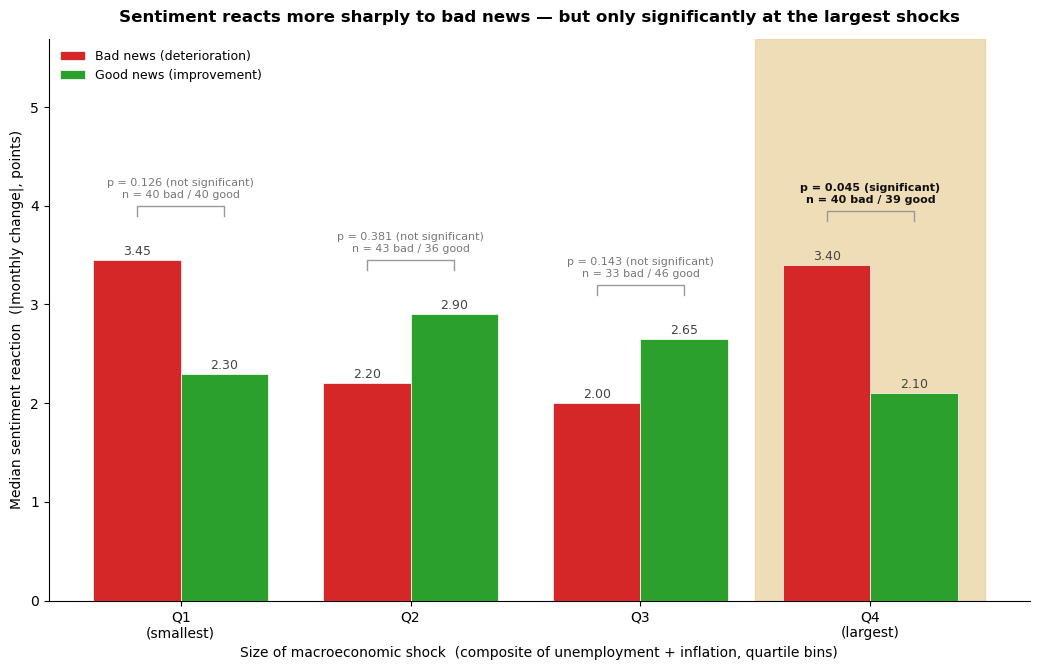

In [153]:
plot_b2_composite()

# Results

### B.1



**Hypothesis/Task B.1:** Enable a user to explore how a change in the 
Federal Funds Rate transmits to mortgage rates, stock prices, inflation, 
and unemployment at different lags, comparing these transmission 
patterns across three macroeconomic regimes (pre-2008, 2008–2020, 
2020–present).

*Design note: An interactive lag/regime selector was prototyped in Plotly (see the
Code section), but the final visualization uses a static small-multiples layout and it
shows all three regimes at once for direct comparison, without making the viewer
remember a previous view ("eyes beat memory"). Every lag/regime combination stays
visible without interaction.*

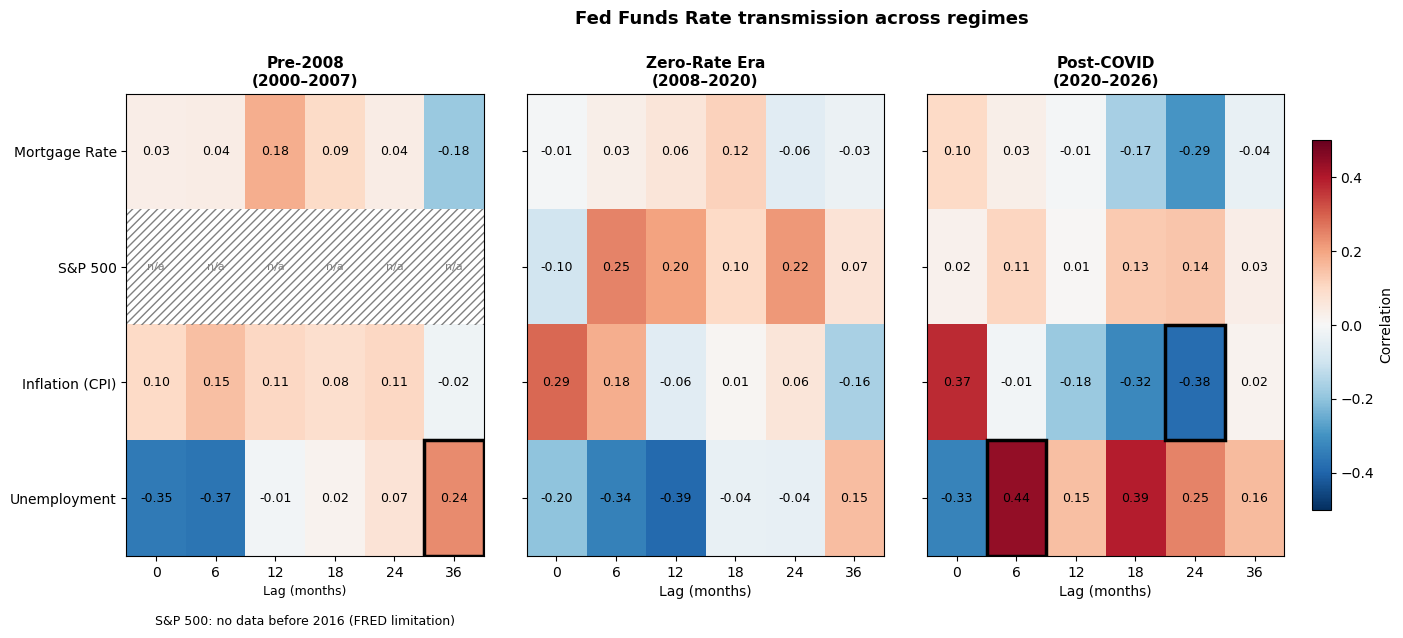

In [154]:
plot_b1_heatmap()

**Description:** The static heatmap shows correlations between Fed Funds Rate changes and four variables across six lags, per regime. Unemployment's correlation flips from negative (lag 0, the Fed reacting to a hot economy) to positive (+0.24) by lag 36 in Pre-2008, confirming our A.1 delayed-effect finding; in Post-COVID the same flip happens 30 months sooner, at lag 6 (+0.44), showing markedly faster transmission. Inflation shows the clearest mechanism: strongly positive at lag 0 in Post-COVID (0.37), reversing to negative by lag 18-24 (-0.32, -0.38) as the Fed's hikes take hold. Mortgage rates and S&P 500 both stay weak; S&P 500 weakens further in Post-COVID (max 0.14) versus the Zero-Rate Era (0.25), consistent with forward-looking markets pricing in expectations rather than realized changes. S&P 500 lacks pre-2016 data, so Pre-2008 cells are marked unavailable rather than misleading. The side-by-side layout makes these speed and strength differences directly comparable.



### B.2



**Hypothesis B.2:** Consumer sentiment (UMCSENT) responds asymmetrically to 
changes in macroeconomic conditions, reacting more sharply to a deterioration 
than to an improvement of comparable magnitude.

*Design note: An earlier approach compared hand-selected "good news" and "bad news"
episodes. It was replaced because the hypothesis turns on comparing conditions "of
comparable magnitude," and hand-picked episodes can neither match shock sizes
objectively nor avoid arbitrary choices about which events to include. Classifying
every month by a composite macro measure and comparing good- vs bad-news months
within bands of comparable shock size delivers that magnitude control rigorously,
across the whole dataset.*

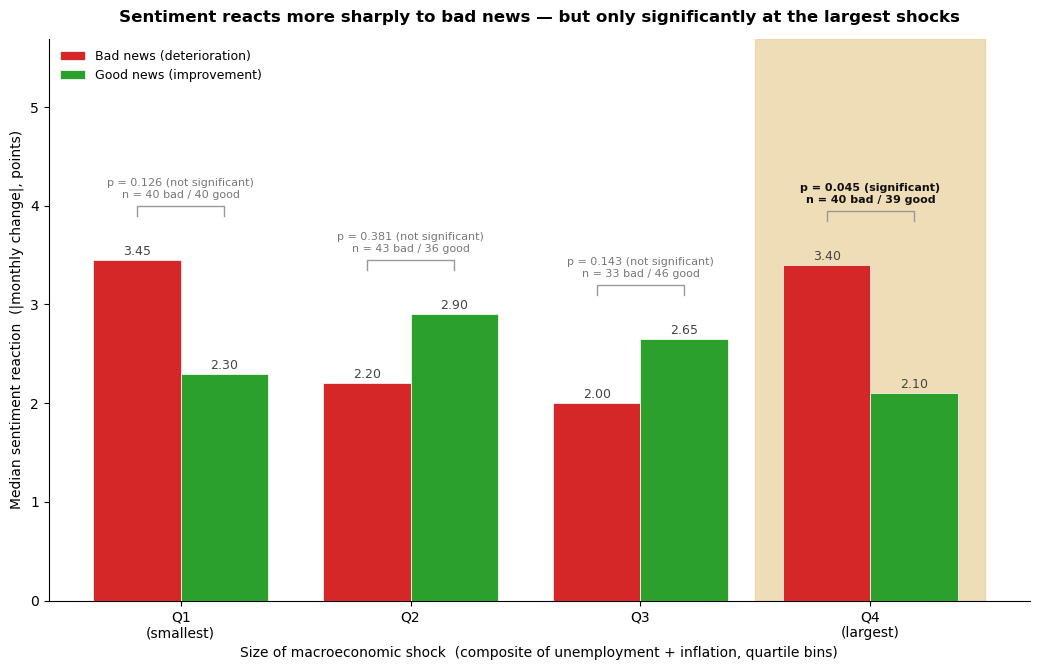

In [155]:
plot_b2_composite()

**Description:** The chart compares sentiment's median monthly reaction in bad- versus good-news months, grouped into quartiles by macro-shock size (a z-scored composite of unemployment and inflation) so the two are matched by magnitude. A Mann-Whitney test per bin shows the bad-vs-good difference is significant only at the largest shocks (Q4, p=0.045) — the major economic events where loss aversion should bite hardest: sentiment reacts more sharply to deterioration than to a comparable improvement (median 3.40 vs 2.10 points, ~40 months each), as the hypothesis predicts. The smaller-shock bins show no significant difference, so their visible gaps — including Q1 — are indistinguishable from noise. The Q4 effect is marginal (it would not survive strict correction for four tests), so we report it as suggestive, not conclusive, though it is corroborated by a swing-rate analysis (Code section) where the sharpest declines outpace the sharpest recoveries.

